In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Incremental black-box optimisation of the welded-beam problem
with PySR surrogates + incremental MINLP constraints *and*
parallel adaptive sampling.
"""
# ------------------------- imports -------------------------
import os, time, pickle, warnings
import numpy as np
import pandas as pd
import sympy as sp
from pysr import PySRRegressor
try:
    from pysr.sr import SearchTimedOut
except ImportError:                   # older / newer PySR
    class SearchTimedOut(Exception):
        pass


from sympy import simplify
from pyomo.environ import (
    ConcreteModel, Var, Objective, Constraint,
    Expression, RangeSet, Reals, Binary, minimize,
    SolverFactory, sin, cos, exp, log, sqrt, value
)
from pyomo.opt import TerminationCondition
from scipy.spatial import cKDTree
from scipy.stats   import qmc
import json

#warnings.filterwarnings("ignore", category=UserWarning)

# ------------------- user-level configuration -------------------
SEEDS      = [12]          # repeatability
N_LHS      = 100          # initial Latin–hyper-cube points (incl. start/end)
N_ITER     = 30           # GP–SCIP cycles
T_LIMIT    = 600          # seconds per SCIP solve
EPS        = 1e-3         # feasibility tol & “protected divide”
M_BIG      = 1e6

x_lower = np.array([0.125,  0.1,  0.1, 0.125])
x_upper = np.array([5.0,   10.0, 10.0, 5.0])
n_dim   = 4

x_start = [2.0, 4.0, 4.0, 2.0]        # fixed first step
x_end   = [0.2443690007, 6.217518385, 8.291471788, 0.244368953]  # fixed last step

N_max_actual = 10                     # number of “move” steps
N_max        = N_max_actual + 1       # include end
delta        = 0.1 * (x_upper - x_lower)

results_folder     = os.path.join(os.getcwd(), "bb_incremental_wb")
os.makedirs(results_folder, exist_ok=True)
INIT_FILE    = os.path.join(results_folder, "initial_LHS_evals.csv")

# ---------------------- physics / simulator ---------------------
P, L              = 6000, 14
tau_max, sigma_max  = 13600, 30000
def welded_beam(x):
    x1,x2,x3,x4 = x
    f = 1.10471*x1**2*x2 + 0.04811*x3*x4*(L + x2)
    R = np.sqrt(x2**2/4 + (x1+x3)**2/4)
    M = P*(L + x2/2)
    J = 2*np.sqrt(0.5)*x1*x2*(x2**2/12 + 0.25*(x1+x3)**2)
    tau_p = P/(np.sqrt(2)*x1*x2)
    tau_pp = M*R/J
    tau = np.sqrt(tau_p**2 + tau_pp**2 + tau_p*tau_pp*x2/R)
    g1 = tau/tau_max - 1
    sigma = 6*P*L/(x4*x3**2)
    g2 = sigma/sigma_max - 1
    g3 = (x1 - x4)/(5.0 - 0.125)
    Pc = 64746.022*(1 - 0.0282346*x3)*x3*x4**3
    g4 = P/Pc - 1
    return f, np.array([g1,g2,g3,g4])

f_start, _ = welded_beam(x_start)
f_end,   _ = welded_beam(x_end)
ideal_f1, nadir_f1 = min(f_start, f_end), max(f_start, f_end)

# ------------------- sympy → pyomo translator -------------------
def sympy_to_pyomo(expr, vmap):
    if getattr(expr, "is_number", False):
        return float(expr)
    #if expr.is_Number:        return float(expr)
    if expr in vmap:          return vmap[expr]
    if expr.is_Symbol:        raise ValueError(f"Unmapped symbol {expr}")

    args = [sympy_to_pyomo(a, vmap) for a in expr.args]
    f = expr.func
    if f is sp.Add:
        out = args[0]
        for a in args[1:]: out = out + a
        return out
    if f is sp.Mul:
        out = args[0]
        for a in args[1:]: out = out * a
        return out
    if f is sp.Pow:           return args[0] ** args[1]
    if f is sp.sin:  return sin(args[0])
    if f is sp.cos:  return cos(args[0])
    if f is sp.exp:  return exp(args[0])
    if f is sp.log:  return log(args[0])
    if f is sp.sqrt: return sqrt(args[0])
    if f is sp.Abs:  return abs(args[0])
    raise NotImplementedError(f"SymPy op {f} not implemented")

# ----------------------- PySR regressor -------------------------
m_gp = PySRRegressor(
    maxsize=20, niterations=60,
    binary_operators=["+","-","*","/"],
    unary_operators=["sin","cos","exp","log","inv(x)=1/x"],
    extra_sympy_mappings={"inv": lambda z: 1/z},
    elementwise_loss="loss(p,t)=(p-t)^2",
    parallelism="multiprocessing", procs=8,
    progress=False, verbosity=0, warm_start=False)

# Fit one surrogate, return simplified Sympy expression
def fit_pysr(X_arr, y_arr, seed):
    m_gp.set_params(random_state=seed)
    try:
        m_gp.fit(X_arr, y_arr)
    except SearchTimedOut:
        print("  [PySR] time-out; using best so far")
    eqs = m_gp.equations_
    if eqs.empty:
        raise RuntimeError("No PySR equations generated")
    best = eqs.sort_values("loss").index[0]
    return simplify(m_gp.sympy(best))

# ------------------ initial Latin-hyper-cube --------------------
if not os.path.exists(INIT_FILE):
    print("Generating shared initial LHS …")
    sampler = qmc.LatinHypercube(d=n_dim, scramble=True)
    X_LHS   = x_lower + (x_upper - x_lower)*sampler.random(N_LHS-2)
    X_init  = np.vstack([x_start, x_end, X_LHS])

    F_init  = np.zeros(len(X_init))
    G_init  = np.zeros((len(X_init), 4))
    for i,x in enumerate(X_init):
        F_init[i], G_init[i] = welded_beam(x)

    df_init = pd.DataFrame(
        np.hstack([X_init, F_init.reshape(-1,1), G_init]),
        columns=[f"x{j+1}" for j in range(4)]
              + ["f_true"] + [f"g{k}" for k in range(1,5)])
    df_init.to_csv(INIT_FILE, index=False)
else:
    print("Shared initial LHS found – using existing file")

# load whatever is there (generated just now or from a previous run)
df_init = pd.read_csv(INIT_FILE)
X_init  = df_init[[f"x{j+1}" for j in range(4)]].to_numpy()
F_init  = df_init["f_true"].to_numpy()
G_init  = df_init[[f"g{k}" for k in range(1,5)]].to_numpy()


def blank_jsonl(path):
    """Append a single blank JSON object to *path*."""
    with open(path, "a", encoding="utf-8") as fp:
        fp.write("{}\n")

def persist_iteration(csv_path, jsonl_path,
                      record, new_pts, write_json=True):
    """
    CSV : append numeric rows for *new_pts* (if any).
    JSON: append *record* (or blank) according to *write_json*.
    """
    new_pts = np.atleast_2d(new_pts)
    if new_pts.size:                 # only when there is data
        evals = np.hstack([new_pts,
                           F_all[-len(new_pts):,None],
                           G_all[-len(new_pts):]])
        pd.DataFrame(evals).to_csv(csv_path,
                                   index=False, header=False, mode="a")

    if write_json:
        with open(jsonl_path, "a") as fp:
            fp.write(json.dumps(record) + "\n")
    else:
        blank_jsonl(jsonl_path)


# ---------------------- helper: build MINLP ---------------------
def build_model(expr_f, expr_gs, sym_vars, add_nonw=True, add_cons=True):
    m = ConcreteModel()
    m.steps = RangeSet(0, N_max)
    m.dims  = RangeSet(0, n_dim-1)
    m.x     = Var(m.steps, m.dims, bounds=lambda m,i,j: (x_lower[j], x_upper[j]))
    m.y     = Var(m.steps, within=Binary)
    m.z     = Var(m.steps, within=Binary)

    # surrogate f & normalisation
    def f_sur(m,i):
        vmap = {sym_vars[j]: m.x[i,j] for j in range(n_dim)}
        return sympy_to_pyomo(expr_f, vmap)
    m.f_surr = Expression(m.steps, rule=f_sur)
    m.f_norm = Expression(m.steps,
        rule=lambda m,i: (m.f_surr[i]-ideal_f1)/(nadir_f1-ideal_f1))

    m.obj = Objective(expr=sum((m.f_norm[i]+1)*m.y[i] for i in m.steps), sense=minimize)

    # constraints
    if add_nonw:
        def nonw(m,i):
            if i==N_max: return Constraint.Skip
            vmap_i   = {sym_vars[j]: m.x[i  ,j] for j in range(n_dim)}
            vmap_ip1 = {sym_vars[j]: m.x[i+1,j] for j in range(n_dim)}
            fi   = sympy_to_pyomo(expr_f, vmap_i)
            fip1 = sympy_to_pyomo(expr_f, vmap_ip1)
            return fip1 <= fi + M_BIG*(2-m.y[i]-m.y[i+1])-EPS
        m.nonw = Constraint(m.steps, rule=nonw)

    m.seq = Constraint(m.steps,
        rule=lambda m,i: Constraint.Skip if i==N_max else m.y[i] >= m.y[i+1])

    def x_low(m,i,j):  return m.x[i,j] >= x_lower[j]*m.y[i] + (x_lower[j]+EPS)*(1-m.y[i])
    def x_high(m,i,j): return m.x[i,j] <= x_upper[j]*m.y[i] + (x_lower[j]+EPS)*(1-m.y[i])
    m.x_low  = Constraint(m.steps, m.dims, rule=x_low)
    m.x_high = Constraint(m.steps, m.dims, rule=x_high)

    def dist(m,i,j):
        if i==0: return Constraint.Skip
        return abs(m.x[i,j]-m.x[i-1,j]) <= delta[j] + M_BIG*(2-m.y[i]-m.y[i-1])
    m.dist = Constraint(m.steps, m.dims, rule=dist)

    m.z1 = Constraint(m.steps,
        rule=lambda m,i: Constraint.Skip if i==N_max else m.z[i] <= m.y[i])
    m.z2 = Constraint(m.steps,
        rule=lambda m,i: Constraint.Skip if i==N_max else m.z[i] <= 1-m.y[i+1])
    m.z3 = Constraint(m.steps,
        rule=lambda m,i: Constraint.Skip if i==N_max else m.z[i] >= m.y[i]-m.y[i+1])
    m.one_z = Constraint(expr=sum(m.z[i] for i in m.steps if i<N_max)==1)

    def end1(m,i,j):
        if i==N_max: return Constraint.Skip
        return m.x[i,j]-x_end[j] <= M_BIG*(1-m.z[i])
    def end2(m,i,j):
        if i==N_max: return Constraint.Skip
        return x_end[j]-m.x[i,j] <= M_BIG*(1-m.z[i])
    m.e1 = Constraint(m.steps, m.dims, rule=end1)
    m.e2 = Constraint(m.steps, m.dims, rule=end2)

    if add_cons:
        for k,gexpr in enumerate(expr_gs):
            def g_rule(m,i,expr=gexpr):
                if i == 0:      # skip start feasibility
                    return Constraint.Skip
                vmap = {sym_vars[j]: m.x[i,j] for j in range(n_dim)}
                return sympy_to_pyomo(expr, vmap) <= M_BIG*(1-m.y[i]) + M_BIG*m.z[i]#Skip feasibility check for the end constraint
            setattr(m, f"g{k+1}", Constraint(m.steps, rule=g_rule))

    # fix start
    for j in m.dims: m.x[0,j].fix(x_start[j])
    m.y[0].fix(1)
    return m

# ----------------------- optimisation loop ----------------------
for SEED in SEEDS:
    seed_dir = os.path.join(results_folder, f"seed{SEED}")
    os.makedirs(seed_dir, exist_ok=True)
    archive_csv = os.path.join(seed_dir, "archive.csv")
    runs_jsonl  = os.path.join(seed_dir, "runs.jsonl")

    # -----------------------------------------------------------------
    # start every seed with the SAME initial archive
    X_all = X_init.copy()
    F_all = F_init.copy()
    G_all = G_init.copy()

    # write header & initial rows
    pd.DataFrame(np.hstack([X_all, F_all.reshape(-1,1), G_all]),
                 columns=[f"x{j+1}" for j in range(4)]
                       + ["f_true"] + [f"g{k}" for k in range(1,5)]
                 ).to_csv(archive_csv, index=False)


    print(f"\n========= Seed {SEED} =========")
    last_feasible_bad_steps = None       # for rule c

    for it in range(1, N_ITER+1):
        print(f"\n--- Iteration {it}/{N_ITER} ---")
        # fit surrogates
        expr_f  = fit_pysr(X_all, F_all, SEED)
        expr_gs = [fit_pysr(X_all, G_all[:,k], SEED) for k in range(4)]
        sym_vars = sp.symbols("x0:4")

        solver = SolverFactory("scip")
        solver.options['limits/time'] = T_LIMIT
        solver.options['presolving/maxrounds']=5

        m = build_model(expr_f, expr_gs, sym_vars, add_nonw=True, add_cons=True)
        res = solver.solve(m, tee=False)
        term = res.solver.termination_condition
        ok_status = term == TerminationCondition.optimal

        record = {
            "iteration": it,
            "expr_f"   : str(expr_f),
            "expr_gs"  : [str(e) for e in expr_gs],
            "scip_status": str(term)
        }


        if not ok_status and last_feasible_bad_steps is None:
            print(" SCIP infeasible → rule d: random samples")
            rand_pts = np.random.uniform(x_lower, x_upper,
                                         size=(N_max+1, n_dim))
            for pt in rand_pts:
                f,g = welded_beam(pt)
                X_all = np.vstack([X_all, pt])
                F_all = np.append(F_all, f)
                G_all = np.vstack([G_all, g])
            record.update({
                "x_steps": [],
                "f_steps": [],
                "g_steps": []
            }) 
            persist_iteration(archive_csv, runs_jsonl, record,
                                rand_pts, write_json=True)
            continue

        elif not ok_status and last_feasible_bad_steps is not None:
            bad_steps = last_feasible_bad_steps.copy()
            print(" SCIP infeasible → resampling based on last feasible scip")

            record.update({
                "x_steps": [],
                "f_steps": [],
                "g_steps": []
            })
            eval_budget = N_max

            # nothing new from SCIP, so empty new_pts:
            persist_iteration(archive_csv, runs_jsonl,
                              record, np.empty((0, n_dim)), write_json=True)


        else:
            # ------ SCIP gave a path ---------------------------
            active = [i for i in m.steps if value(m.y[i])>0.5 and i>0]
            bad_steps = []

            eval_budget = N_max           # rule: budget equals max steps
            #used_budget = 0
            new_pts, new_fs, new_gs = [], [], []   #  collect for JSONL
            for i in active:
                x_i = np.array([value(m.x[i,j]) for j in range(n_dim)])
                f_i,g_i = welded_beam(x_i)
                feas = (g_i<=EPS).all()
                print(f" step {i}: x={np.round(x_i,4)}, f={f_i:.3f}, feas={feas}")
                X_all = np.vstack([X_all, x_i])
                F_all = np.append(F_all, f_i)
                G_all = np.vstack([G_all, g_i])
                new_pts.append(x_i)
                new_fs.append(float(f_i))
                new_gs.append(g_i.tolist())
                #used_budget += 1
                if not feas: bad_steps.append(x_i)
            new_pts_arr = np.vstack(new_pts)
            record.update({
                "x_steps": new_pts_arr.tolist(),
                "f_steps": new_fs,
                "g_steps": new_gs
            })            
            persist_iteration(archive_csv, runs_jsonl, record, new_pts_arr,
                            write_json=True)

            if not bad_steps:      # rule 1a: all feasible → terminate
                print("\nAll active steps feasible – optimisation finished.")
                break

        # ------------- parallel sampling (b / c) -------------
        k_bad = len(bad_steps)
        per_bad = max((eval_budget)//k_bad, 1)
        extra = []
        if per_bad>0:
            tree = cKDTree(X_all)
            for bad in bad_steps:
                _, idx = tree.query(bad, k=min(n_dim,len(X_all)))
                box_min = X_all[idx].min(axis=0)
                box_max = X_all[idx].max(axis=0)
                samples = np.random.uniform(box_min, box_max,
                                            size=(per_bad, n_dim))
                extra.append(samples)
                for pt in samples:
                    f,g = welded_beam(pt)
                    X_all = np.vstack([X_all, pt])
                    F_all = np.append(F_all, f)
                    G_all = np.vstack([G_all, g])

        # >>>>>>>>>>>>>> NEW: save the adaptive-sampling points <<<<<<<<<<<<<<
        if extra:                              # only when we actually added some
            extra = np.vstack(extra)           # list → (m,4) array
            persist_iteration(archive_csv,
                              runs_jsonl,
                              {},              # blank record in JSONL
                              extra,
                              write_json=False)
        # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

        last_feasible_bad_steps = bad_steps.copy()

    # ----------- pickle final surrogate of this seed -------------
    with open(os.path.join(seed_dir, "best_surrogate.pkl"), "wb") as fp:
        pickle.dump({"expr_f": str(expr_f),
                     "expr_gs":[str(e) for e in expr_gs]}, fp)

    print(f"\n🔔 Finished seed {SEED} – full archive in {archive_csv}")


2.3809563570817236
\begin{table}[ht]
\centering
\caption{Incremental SR--embedded MINLP (31 seeds)}
\begin{tabular}{lccccc}
\toprule
Metric & Min & Max & Mean & Median & Std \\
\midrule
Normalised objective & 7.844 & 8.039 & 7.859 & 7.851 & 0.035 \\
Iterations & 1.0 & 8.0 & 3.9 & 4.0 & 2.0 \\
True evaluations & 105 & 217 & 151 & 153 & 31 \\
\bottomrule
\end{tabular}
\label{tab:bb_inc_stats}
\end{table}


/var/folders/dh/hyxq3sgn7hq88jxkcjz5qh7w0000gn/T/ipykernel_60929/2699609272.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


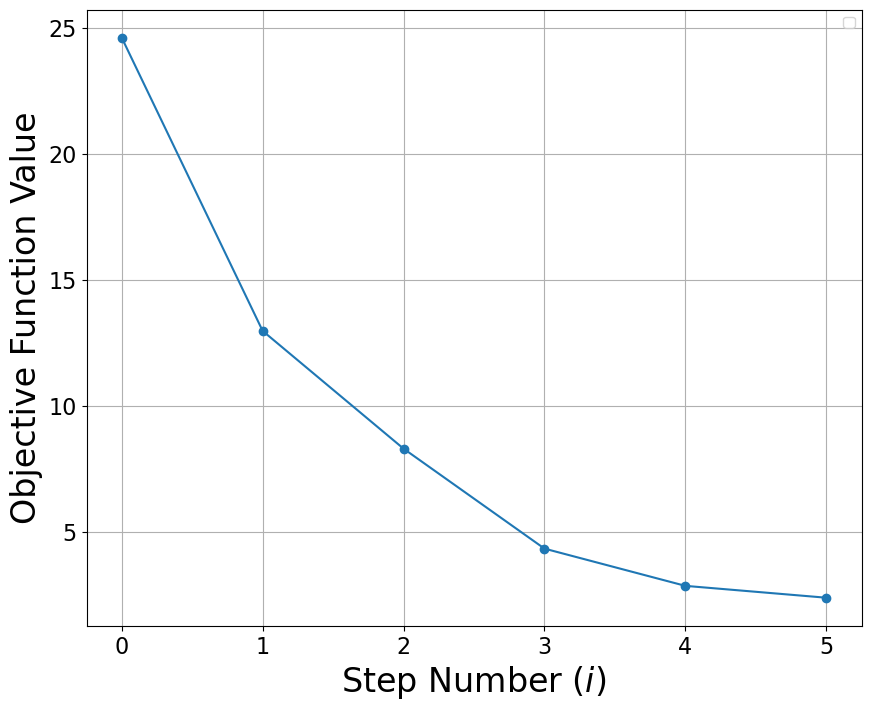


LaTeX table printed above.
Plot saved to:
  Results-Incremental-Optimization-WB/figures/BB_inc_median.png
  Results-Incremental-Optimization-WB/figures/BB_inc_median.eps


In [1]:
# ----------------------------------------------------------------
# Post-processing for incremental SR–embedded MINLP (welded beam)
#    – includes step-0 and evaluation-count statistics –
# ----------------------------------------------------------------
import os, json, numpy as np, matplotlib.pyplot as plt

# --------------- constants (must match main run) ---------------
#SEEDS       = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
SEEDS = list(range(1, 32))         # 1..31
RESULTS_DIR = "Results-Incremental-Optimization-WB"           # root folder with seed subdirs

x_start = np.array([2.0, 4.0, 4.0, 2.0])    # existing design
x_end   = np.array([0.2443690007, 6.217518385, 8.291471788, 0.244368953])

# ---------------------- physics / simulator ---------------------
P, L              = 6000, 14
tau_max, sigma_max  = 13600, 30000
def welded_beam(x):
    x1,x2,x3,x4 = x
    f = 1.10471*x1**2*x2 + 0.04811*x3*x4*(L + x2)
    R = np.sqrt(x2**2/4 + (x1+x3)**2/4)
    M = P*(L + x2/2)
    J = 2*np.sqrt(0.5)*x1*x2*(x2**2/12 + 0.25*(x1+x3)**2)
    tau_p = P/(np.sqrt(2)*x1*x2)
    tau_pp = M*R/J
    tau = np.sqrt(tau_p**2 + tau_pp**2 + tau_p*tau_pp*x2/R)
    g1 = tau/tau_max - 1
    sigma = 6*P*L/(x4*x3**2)
    g2 = sigma/sigma_max - 1
    g3 = (x1 - x4)/(5.0 - 0.125)
    Pc = 64746.022*(1 - 0.0282346*x3)*x3*x4**3
    g4 = P/Pc - 1
    return f, np.array([g1,g2,g3,g4])

f_start = welded_beam(x_start)[0]
f_end   = welded_beam(x_end)[0]
print(f_end)
ideal_f1, nadir_f1 = min(f_start, f_end), max(f_start, f_end)

# ------------- helpers to process one seed directory ----------
def load_final_record(seed):
    """Return (final_record_dict, n_iterations) for given seed."""
    jpath = os.path.join(RESULTS_DIR, f"seed{seed}", "runs.jsonl")
    records = [json.loads(l) for l in open(jpath, "r") if l.strip()]
    final   = next(r for r in reversed(records) if r.get("x_steps"))
    n_iter  = max(r.get("iteration", 0) for r in records if "iteration" in r)
    return final, n_iter

def eval_count(seed):
    """Total number of true evaluations = rows in archive.csv minus header."""
    apath = os.path.join(RESULTS_DIR, f"seed{seed}", "archive.csv")
    with open(apath, "r") as fp:
        return sum(1 for _ in fp) - 1   # minus header row

def incremental_obj(full_f):
    full_f = np.asarray(full_f, float)
    return float(np.sum((full_f - ideal_f1)/(nadir_f1 - ideal_f1) + 1.0))

# --------------- gather metrics across all seeds --------------
obj_vals, iter_vals, eval_vals, seed_obj_pairs = [], [], [], []
for s in SEEDS:
    rec, n_it = load_final_record(s)
    f_full = np.concatenate(([f_start], np.asarray(rec["f_steps"], float)))
    obj_vals.append(incremental_obj(f_full))
    iter_vals.append(n_it)
    eval_vals.append(eval_count(s))
    seed_obj_pairs.append((s, obj_vals[-1]))

obj_arr  = np.array(obj_vals)
iter_arr = np.array(iter_vals)
eval_arr = np.array(eval_vals)

# ------------------------ LaTeX table -------------------------
def latex_row(metric, arr, fmt="{:.3f}"):
    return (f"{metric} & {fmt.format(arr.min())} & {fmt.format(arr.max())} & "
            f"{fmt.format(arr.mean())} & {fmt.format(np.median(arr))} & "
            f"{fmt.format(arr.std())} \\\\")

print(r"\begin{table}[ht]")
print(r"\centering")
print(f"\\caption{{Incremental SR--embedded MINLP ({len(SEEDS)} seeds)}}")
print(r"\begin{tabular}{lccccc}")
print(r"\toprule")
print(r"Metric & Min & Max & Mean & Median & Std \\")
print(r"\midrule")
print(latex_row("Normalised objective", obj_arr))
print(latex_row("Iterations",           iter_arr, fmt="{:.1f}"))
print(latex_row("True evaluations",     eval_arr, fmt="{:.0f}"))
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\label{tab:bb_inc_stats}")
print(r"\end{table}")

# ------ choose seed closest to median objective & plot ---------
median_seed = min(seed_obj_pairs,
                  key=lambda t: abs(t[1] - np.median(obj_arr)))[0]
rec, _   = load_final_record(median_seed)
f_vals   = np.concatenate(([f_start], np.asarray(rec["f_steps"], float)))

fig, ax = plt.subplots(figsize=(10, 8))
# Increase axis‐label font size to 16
ax.set_xlabel('Step Number ($i$)', fontsize=24)
ax.set_ylabel('Objective Function Value', fontsize=24)

# Increase tick‐label font size to 14
ax.tick_params(axis='both', labelsize=16)
ax.plot(range(len(f_vals)), f_vals, marker='o', linestyle='-')
ax.legend()
ax.grid(True)

# --------------- save figure (PNG & EPS) -----------------------
figures_dir = os.path.join(RESULTS_DIR, "figures")
os.makedirs(figures_dir, exist_ok=True)
png_path = os.path.join(figures_dir, "BB_inc_median.png")
eps_path = os.path.join(figures_dir, "BB_inc_median.eps")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(eps_path, format="eps", bbox_inches="tight")
plt.show()

print("\nLaTeX table printed above.")
print(f"Plot saved to:\n  {png_path}\n  {eps_path}")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


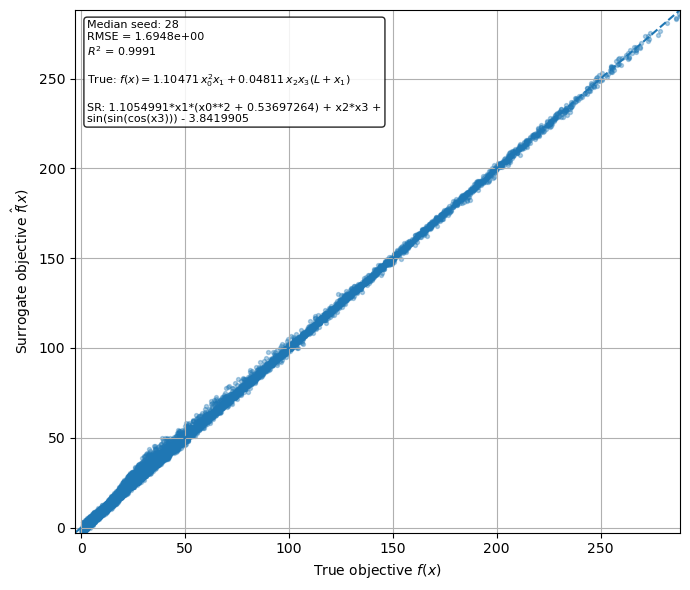

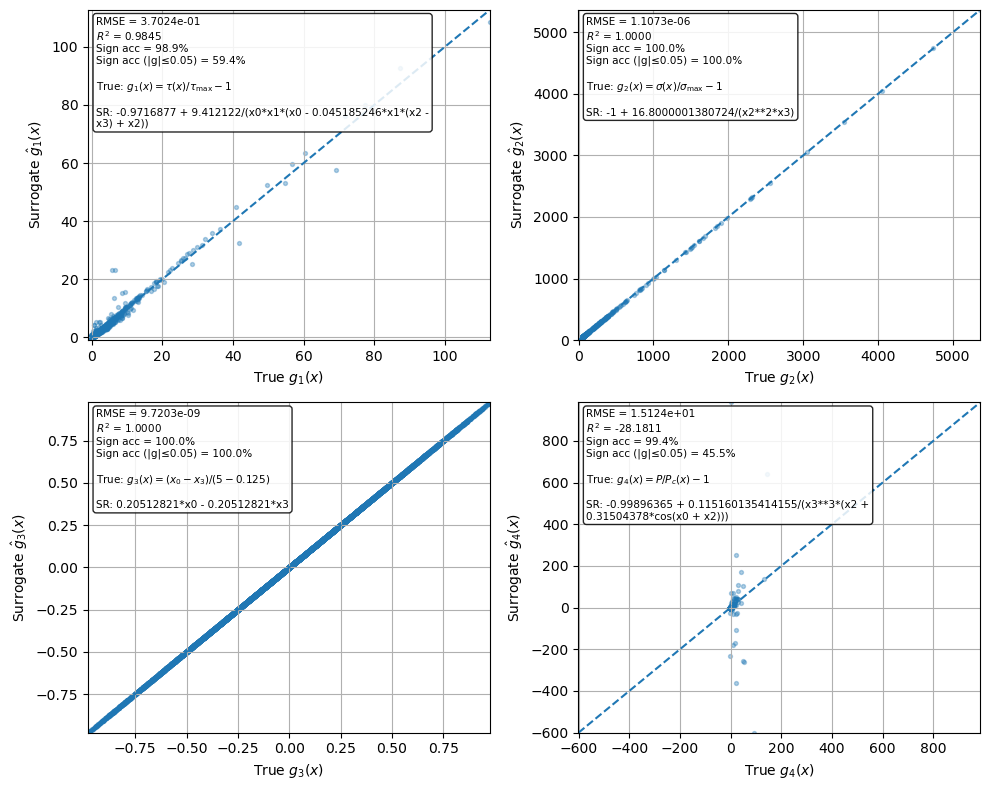

Saved:
  Results-Incremental-Optimization-WB/figures/pysr_parity_f_seed28.png
  Results-Incremental-Optimization-WB/figures/pysr_parity_g_seed28.png


In [8]:
import os, json, textwrap
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# -------------------- user settings --------------------
RESULTS_DIR = "Results-Incremental-Optimization-WB"
SEEDS = list(range(1, 32))         # 1..31
N_TEST = 10_000                    # random test points
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# bounds must match your run
x_lower = np.array([0.125,  0.1,  0.1, 0.125], dtype=float)
x_upper = np.array([5.0,   10.0, 10.0, 5.0], dtype=float)

# welded-beam constants must match your run
P, L = 6000, 14
tau_max, sigma_max = 13600, 30000

x_start = np.array([2.0, 4.0, 4.0, 2.0], dtype=float)
x_end   = np.array([0.2443690007, 6.217518385, 8.291471788, 0.244368953], dtype=float)

# -------------------- true model (vectorized) --------------------
def welded_beam_batch(X):
    """X: (N,4). Returns f_true: (N,), g_true: (N,4)."""
    x1 = X[:, 0]
    x2 = X[:, 1]
    x3 = X[:, 2]
    x4 = X[:, 3]

    f = 1.10471 * x1**2 * x2 + 0.04811 * x3 * x4 * (L + x2)

    R = np.sqrt(x2**2/4.0 + (x1 + x3)**2/4.0)
    M = P * (L + x2/2.0)
    J = 2.0*np.sqrt(0.5)*x1*x2*(x2**2/12.0 + 0.25*(x1 + x3)**2)

    tau_p  = P / (np.sqrt(2.0)*x1*x2)
    tau_pp = M*R/J
    tau = np.sqrt(tau_p**2 + tau_pp**2 + tau_p*tau_pp*x2/R)
    g1 = tau/tau_max - 1.0

    sigma = 6.0*P*L/(x4*x3**2)
    g2 = sigma/sigma_max - 1.0

    g3 = (x1 - x4)/(5.0 - 0.125)

    Pc = 64746.022*(1.0 - 0.0282346*x3)*x3*x4**3
    g4 = P/Pc - 1.0

    G = np.vstack([g1, g2, g3, g4]).T
    return f, G

def welded_beam_single(x):
    f, g = welded_beam_batch(np.atleast_2d(x))
    return float(f[0]), g[0]

# normalisation constants used in your incremental objective
f_start = welded_beam_single(x_start)[0]
f_end   = welded_beam_single(x_end)[0]
ideal_f1, nadir_f1 = min(f_start, f_end), max(f_start, f_end)

def incremental_obj(full_f):
    full_f = np.asarray(full_f, float)
    return float(np.sum((full_f - ideal_f1)/(nadir_f1 - ideal_f1) + 1.0))

# -------------------- helpers to read runs --------------------
def load_records(seed):
    jpath = os.path.join(RESULTS_DIR, f"seed{seed}", "runs.jsonl")
    records = []
    with open(jpath, "r", encoding="utf-8") as fp:
        for line in fp:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

def load_final_record(seed):
    """Last record that contains x_steps (matches your current logic)."""
    records = load_records(seed)
    final = next(r for r in reversed(records) if r.get("x_steps"))
    return final

def pick_median_seed():
    pairs = []
    for s in SEEDS:
        rec = load_final_record(s)
        f_steps = np.asarray(rec["f_steps"], float)
        f_full = np.concatenate(([f_start], f_steps))
        obj = incremental_obj(f_full)
        pairs.append((s, obj))
    objs = np.array([p[1] for p in pairs])
    med = np.median(objs)
    median_seed = min(pairs, key=lambda t: abs(t[1] - med))[0]
    return median_seed, pairs

# -------------------- sympy -> numpy --------------------
def sympy_fn(expr_str):
    """
    Builds a numpy-callable function from a PySR sympy string.
    PySR typically uses x0,x1,x2,x3 as variables.
    """
    x0, x1, x2, x3 = sp.symbols("x0 x1 x2 x3")
    expr = sp.sympify(expr_str)
    fn = sp.lambdify((x0, x1, x2, x3), expr, modules=["numpy"])
    return expr, fn

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

# -------------------- main: build parity plots --------------------
median_seed, seed_obj_pairs = pick_median_seed()
rec = load_final_record(median_seed)

expr_f_str = rec["expr_f"]
expr_gs_str = rec["expr_gs"]

expr_f, f_sr_fn = sympy_fn(expr_f_str)
expr_gs = []
g_sr_fns = []
for s in expr_gs_str:
    e, fn = sympy_fn(s)
    expr_gs.append(e)
    g_sr_fns.append(fn)

# test points
rng = np.random.default_rng(0)
X = rng.uniform(x_lower, x_upper, size=(N_TEST, 4))

# true evals
f_true, g_true = welded_beam_batch(X)

# surrogate evals
f_pred = f_sr_fn(X[:,0], X[:,1], X[:,2], X[:,3])
f_pred = np.asarray(f_pred, float)

g_pred = np.zeros_like(g_true, dtype=float)
for k in range(4):
    gp = g_sr_fns[k](X[:,0], X[:,1], X[:,2], X[:,3])
    g_pred[:, k] = np.asarray(gp, float)

f_true_str = r"$f(x)=1.10471\,x_0^2x_1+0.04811\,x_2x_3(L+x_1)$"
g_true_strs = [
    r"$g_1(x)=\tau(x)/\tau_{\max}-1$",
    r"$g_2(x)=\sigma(x)/\sigma_{\max}-1$",
    r"$g_3(x)=(x_0-x_3)/(5-0.125)$",
    r"$g_4(x)=P/P_c(x)-1$",
]

def add_identity_line(ax, y_min, y_max):
    lo = min(y_min, y_max)
    hi = max(y_min, y_max)
    ax.plot([lo, hi], [lo, hi], linestyle="--")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

# ---------- Figure 1: objective ----------
fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1.scatter(f_true, f_pred, s=8, alpha=0.35)
add_identity_line(ax1, min(f_true.min(), f_pred.min()), max(f_true.max(), f_pred.max()))
ax1.set_xlabel("True objective $f(x)$")
ax1.set_ylabel("Surrogate objective $\\hat{f}(x)$")
ax1.grid(True)

txt = (
    f"Median seed: {median_seed}\n"
    f"RMSE = {rmse(f_true, f_pred):.4e}\n"
    f"$R^2$ = {r2_score(f_true, f_pred):.4f}\n\n"
    f"True: {f_true_str}\n\n"
    "SR: " + textwrap.fill(str(expr_f), width=60)
)
ax1.text(0.02, 0.98, txt, transform=ax1.transAxes, va="top", ha="left", fontsize=8,
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig1.tight_layout()
fig1_png = os.path.join(FIG_DIR, f"pysr_parity_f_seed{median_seed}.png")
fig1_eps = os.path.join(FIG_DIR, f"pysr_parity_f_seed{median_seed}.eps")
fig1.savefig(fig1_png, dpi=300, bbox_inches="tight")
fig1.savefig(fig1_eps, format="eps", bbox_inches="tight")

# ---------- Figure 2: constraints (2x2) ----------
fig2, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for k, ax in enumerate(axes):
    yt = g_true[:, k]
    yp = g_pred[:, k]

    ax.scatter(yt, yp, s=8, alpha=0.35)
    add_identity_line(ax, min(yt.min(), yp.min()), max(yt.max(), yp.max()))
    ax.set_xlabel(f"True $g_{k+1}(x)$")
    ax.set_ylabel(f"Surrogate $\\hat{{g}}_{k+1}(x)$")
    ax.grid(True)

    # sign agreement (overall + near boundary)
    sign_acc = 100.0*np.mean((yt <= 0.0) == (yp <= 0.0))
    eps_band = 0.05
    mask = np.abs(yt) <= eps_band
    sign_acc_band = 100.0*np.mean(((yt[mask] <= 0.0) == (yp[mask] <= 0.0))) if np.any(mask) else np.nan

    txt = (
        f"RMSE = {rmse(yt, yp):.4e}\n"
        f"$R^2$ = {r2_score(yt, yp):.4f}\n"
        f"Sign acc = {sign_acc:.1f}%\n"
        f"Sign acc (|g|≤{eps_band}) = {sign_acc_band:.1f}%\n\n"
        f"True: {g_true_strs[k]}\n\n"
        "SR: " + textwrap.fill(str(expr_gs[k]), width=55)
    )
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left", fontsize=7.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

#fig2.suptitle(f"Parity plots for constraints (median seed {median_seed})", y=1.02)
fig2.tight_layout()

fig2_png = os.path.join(FIG_DIR, f"pysr_parity_g_seed{median_seed}.png")
fig2_eps = os.path.join(FIG_DIR, f"pysr_parity_g_seed{median_seed}.eps")
fig2.savefig(fig2_png, dpi=300, bbox_inches="tight")
fig2.savefig(fig2_eps, format="eps", bbox_inches="tight")

plt.show()

print("Saved:")
print(" ", fig1_png)
print(" ", fig2_png)


In [5]:
# ============================================================
# Extra post-processing: step-wise (true vs surrogate) f & g
# and check whether g4 is ever an active/binding constraint
# (use the *final* surrogate stored in `rec["expr_f"]`, `rec["expr_gs"]`)
# ============================================================
import numpy as np
import pandas as pd

# ---------- configuration ----------
FEAS_TOL_TRUE = 0.0       # feasibility definition: g(x) <= 0
ACTIVE_EPS    = 1e-2      # "near-active" threshold: g(x) >= -ACTIVE_EPS is close to binding
PRINT_MAX_ROWS = 200      # safety for printing

# ---------- get the final path from runs.jsonl ----------
# rec is already the final record you used above
X_steps = np.asarray(rec["x_steps"], dtype=float)
if X_steps.ndim == 1:
    X_steps = X_steps[None, :]

# include the fixed start (so you see the full incremental path)
X_path = np.vstack([x_start.reshape(1, -1), X_steps])

# ---------- true evaluations (vectorized) ----------
f_true_path, g_true_path = welded_beam_batch(X_path)

# ---------- surrogate evaluations (vectorized) ----------
f_hat_path = np.asarray(f_sr_fn(X_path[:,0], X_path[:,1], X_path[:,2], X_path[:,3]), dtype=float)

g_hat_path = np.column_stack([
    np.asarray(fn(X_path[:,0], X_path[:,1], X_path[:,2], X_path[:,3]), dtype=float)
    for fn in g_sr_fns
])

# ---------- feasibility & "activeness" analysis ----------
feas_mask = np.all(g_true_path <= FEAS_TOL_TRUE, axis=1)

# most-active constraint per step (largest g_i)
g_true_max = g_true_path.max(axis=1)
g_true_argmax = g_true_path.argmax(axis=1) + 1  # 1..4

# near-binding flags
near_active = (g_true_path >= -ACTIVE_EPS)  # (n_steps, 4) boolean
near_active_any = near_active.any(axis=1)
near_active_g4 = near_active[:, 3]          # g4 near-binding

# g4 "dominant" (actually the max g) among constraints
g4_is_max = (g_true_argmax == 4)

# ---------- build a readable table ----------
rows = []
for i in range(X_path.shape[0]):
    rows.append({
        "step": i,
        "feasible_true": bool(feas_mask[i]),
        "f_true": float(f_true_path[i]),
        "f_hat": float(f_hat_path[i]),
        "f_err": float(f_hat_path[i] - f_true_path[i]),
        "g1_true": float(g_true_path[i,0]),
        "g2_true": float(g_true_path[i,1]),
        "g3_true": float(g_true_path[i,2]),
        "g4_true": float(g_true_path[i,3]),
        "g1_hat":  float(g_hat_path[i,0]),
        "g2_hat":  float(g_hat_path[i,1]),
        "g3_hat":  float(g_hat_path[i,2]),
        "g4_hat":  float(g_hat_path[i,3]),
        "max_g_true": float(g_true_max[i]),
        "argmax_g_true": int(g_true_argmax[i]),
        "any_near_active": bool(near_active_any[i]),
        "g4_near_active": bool(near_active_g4[i]),
        "g4_is_max": bool(g4_is_max[i]),
        "x1": float(X_path[i,0]),
        "x2": float(X_path[i,1]),
        "x3": float(X_path[i,2]),
        "x4": float(X_path[i,3]),
    })

df_steps = pd.DataFrame(rows)

# Show only the feasible steps (what you want to reason about for "active constraints")
df_feas = df_steps[df_steps["feasible_true"]].copy()

# ---------- print tables ----------
print("\n=== Step-wise TRUE vs SURROGATE (ALL steps, incl. start) ===")
with pd.option_context("display.max_rows", min(PRINT_MAX_ROWS, len(df_steps)),
                       "display.max_columns", 200,
                       "display.width", 220):
    print(df_steps[[
        "step","feasible_true","f_true","f_hat","f_err",
        "g1_true","g2_true","g3_true","g4_true",
        "g1_hat","g2_hat","g3_hat","g4_hat",
        "max_g_true","argmax_g_true",
        "any_near_active","g4_near_active","g4_is_max"
    ]].to_string(index=False))

print("\n=== Feasible steps ONLY (used to assess whether g4 is active/binding) ===")
with pd.option_context("display.max_rows", min(PRINT_MAX_ROWS, len(df_feas)),
                       "display.max_columns", 200,
                       "display.width", 220):
    print(df_feas[[
        "step","f_true","f_hat","f_err",
        "g1_true","g2_true","g3_true","g4_true",
        "max_g_true","argmax_g_true",
        "any_near_active","g4_near_active","g4_is_max"
    ]].to_string(index=False))

# ---------- concise summary stats to support your claim ----------
n_all = len(df_steps)
n_feas = len(df_feas)

print("\n=== Summary ===")
print(f"Median seed used: {median_seed}")
print(f"Total steps (incl. start): {n_all}")
print(f"Feasible steps (true g<=0): {n_feas}")

if n_feas > 0:
    g4_vals = df_feas["g4_true"].to_numpy()
    print(f"\n[g4 on feasible steps] min={g4_vals.min():.4e}, max={g4_vals.max():.4e}, median={np.median(g4_vals):.4e}")
    print(f"Feasible steps with g4 near-binding (g4 >= -{ACTIVE_EPS}): {int(df_feas['g4_near_active'].sum())} / {n_feas}")
    print(f"Feasible steps where g4 is the most-active constraint (argmax g = 4): {int(df_feas['g4_is_max'].sum())} / {n_feas}")

    # Also show how often each constraint is near-active on feasible steps
    counts_near = near_active[feas_mask].sum(axis=0) if np.any(feas_mask) else np.zeros(4, dtype=int)
    print("\nNear-binding counts on feasible steps (g_i >= -ACTIVE_EPS):")
    for i, c in enumerate(counts_near, start=1):
        print(f"  g{i}: {int(c)} / {n_feas}")

else:
    print("No feasible steps found in the final path (unexpected if the run terminated on feasibility).")



=== Step-wise TRUE vs SURROGATE (ALL steps, incl. start) ===
 step  feasible_true    f_true     f_hat     f_err       g1_true       g2_true       g3_true       g4_true    g1_hat        g2_hat        g3_hat    g4_hat    max_g_true  argmax_g_true  any_near_active  g4_near_active  g4_is_max
    0           True 24.603200 23.827167 -0.776033 -7.584802e-01 -4.750000e-01  0.000000e+00 -9.967354e-01 -0.763031 -4.750000e-01  0.000000e+00 -0.995618  0.000000e+00              3             True           False      False
    1           True 12.968167 12.166658 -0.801509 -5.883206e-01 -4.079711e-01 -2.615334e-10 -9.929552e-01 -0.593082 -4.079711e-01 -2.615335e-10 -0.991754 -2.615334e-10              3             True           False      False
    2           True  8.295218  7.788195 -0.507023 -4.739284e-01 -4.212088e-01 -1.448582e-10 -9.809698e-01 -0.477014 -4.212088e-01 -1.448582e-10 -0.979989 -1.448582e-10              3             True           False      False
    3           True  4.32

In [6]:
# ============================================================
# Step-wise (true vs surrogate) table for the final returned path
# Reorders columns as: f, fhat, f%err, g1, g1hat, g1%err, ..., g4...
# Also prints LaTeX for the table (booktabs + resizebox).
# ============================================================
import numpy as np
import pandas as pd

# Match your run's feasibility tolerance if you want "feasible_true" to align
# with the solver/algorithm (your run used EPS = 1e-3).
FEAS_TOL_TRUE = 1e-3

# Percent-error stabilization: percent errors blow up when true value ~ 0.
# This epsilon ONLY affects the percent error denominator, not the feasibility.
PCT_DEN_EPS = 1e-6

# ---------- rebuild the final path (include the fixed start) ----------
X_steps = np.asarray(rec["x_steps"], dtype=float)
if X_steps.ndim == 1:
    X_steps = X_steps[None, :]
X_path = np.vstack([x_start.reshape(1, -1), X_steps])

# ---------- true evaluations ----------
f_true_path, g_true_path = welded_beam_batch(X_path)

# ---------- surrogate evaluations (final surrogate from `rec`) ----------
f_hat_path = np.asarray(f_sr_fn(X_path[:,0], X_path[:,1], X_path[:,2], X_path[:,3]), dtype=float)
g_hat_path = np.column_stack([
    np.asarray(fn(X_path[:,0], X_path[:,1], X_path[:,2], X_path[:,3]), dtype=float)
    for fn in g_sr_fns
])

# ---------- helpers ----------
def pct_err(y_true, y_pred, eps=PCT_DEN_EPS):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.maximum(np.abs(y_true), eps)
    return 100.0 * (y_pred - y_true) / denom  # signed percent error

feas_mask = np.all(g_true_path <= FEAS_TOL_TRUE, axis=1)

# ---------- build the single wide table ----------
df = pd.DataFrame({
    "step": np.arange(X_path.shape[0]),
    "feasible": feas_mask,
    "f": f_true_path,
    "f_hat": f_hat_path,
    "f_%err": pct_err(f_true_path, f_hat_path),
})

for k in range(4):
    df[f"g{k+1}"] = g_true_path[:, k]
    df[f"g{k+1}_hat"] = g_hat_path[:, k]
    df[f"g{k+1}_%err"] = pct_err(g_true_path[:, k], g_hat_path[:, k])

# optional: include x values (comment out if you don't want them)
# for j in range(4):
#     df[f"x{j+1}"] = X_path[:, j]

# reorder columns exactly as requested
cols = ["step", "feasible", "f", "f_hat", "f_%err"]
for k in range(1, 5):
    cols += [f"g{k}", f"g{k}_hat", f"g{k}_%err"]
df = df[cols]

print("\n=== Step-wise TRUE vs SURROGATE (single table) ===")
with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 220):
    print(df.to_string(index=False))

# ---------- LaTeX table printing ----------
def fmt_num(x):
    # compact scientific formatting that stays readable
    x = float(x)
    ax = abs(x)
    if ax != 0 and (ax < 1e-3 or ax >= 1e3):
        return f"{x:.2e}"
    return f"{x:.6f}"

def fmt_pct(x):
    return f"{float(x):.2f}"

latex_lines = []
latex_lines.append(r"\begin{table}[t]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Welded-beam (incremental path, median run). Step-wise comparison of true model values and final PySR surrogates. Percent error is reported as $100(\hat{y}-y)/\max(|y|,\epsilon)$ with $\epsilon=%g$ (to avoid ill-conditioning when $y\approx 0$).}" % PCT_DEN_EPS)
latex_lines.append(r"\label{tab:wb_stepwise_true_vs_sr}")
latex_lines.append(r"\resizebox{\linewidth}{!}{%")
latex_lines.append(r"\begin{tabular}{r c r r r r r r r r r r r r}")
latex_lines.append(r"\toprule")
latex_lines.append(r"Step & Feas. & $f$ & $\hat f$ & \%err & $g_1$ & $\hat g_1$ & \%err & $g_2$ & $\hat g_2$ & \%err & $g_3$ & $\hat g_3$ & \%err & $g_4$ & $\hat g_4$ & \%err \\")
latex_lines.append(r"\midrule")

for _, row in df.iterrows():
    latex_lines.append(
        f"{int(row['step'])} & "
        f"{('T' if row['feasible'] else 'F')} & "
        f"{fmt_num(row['f'])} & {fmt_num(row['f_hat'])} & {fmt_pct(row['f_%err'])} & "
        f"{fmt_num(row['g1'])} & {fmt_num(row['g1_hat'])} & {fmt_pct(row['g1_%err'])} & "
        f"{fmt_num(row['g2'])} & {fmt_num(row['g2_hat'])} & {fmt_pct(row['g2_%err'])} & "
        f"{fmt_num(row['g3'])} & {fmt_num(row['g3_hat'])} & {fmt_pct(row['g3_%err'])} & "
        f"{fmt_num(row['g4'])} & {fmt_num(row['g4_hat'])} & {fmt_pct(row['g4_%err'])} \\\\"
    )

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}}")
latex_lines.append(r"\end{table}")

print("\n=== LaTeX for step-wise table ===\n")
print("\n".join(latex_lines))



=== Step-wise TRUE vs SURROGATE (single table) ===
 step  feasible         f     f_hat    f_%err            g1    g1_hat       g1_%err            g2        g2_hat      g2_%err            g3        g3_hat       g3_%err            g4    g4_hat       g4_%err
    0      True 24.603200 23.827167 -3.154196 -7.584802e-01 -0.763031 -5.999764e-01 -4.750000e-01 -4.750000e-01 9.083710e-07  0.000000e+00  0.000000e+00  0.000000e+00 -9.967354e-01 -0.995618  1.121113e-01
    1      True 12.968167 12.166658 -6.180589 -5.883206e-01 -0.593082 -8.092389e-01 -4.079711e-01 -4.079711e-01 1.192645e-06 -2.615334e-10 -2.615335e-10 -3.416071e-09 -9.929552e-01 -0.991754  1.209352e-01
    2      True  8.295218  7.788195 -6.112233 -4.739284e-01 -0.477014 -6.509661e-01 -4.212088e-01 -4.212088e-01 1.129333e-06 -1.448582e-10 -1.448582e-10  1.209858e-09 -9.809698e-01 -0.979989  9.995864e-02
    3      True  4.328966  4.106193 -5.146102 -2.465716e-01 -0.252193 -2.279783e+00 -2.153616e-01 -2.153616e-01 2.994324e-06 -4.